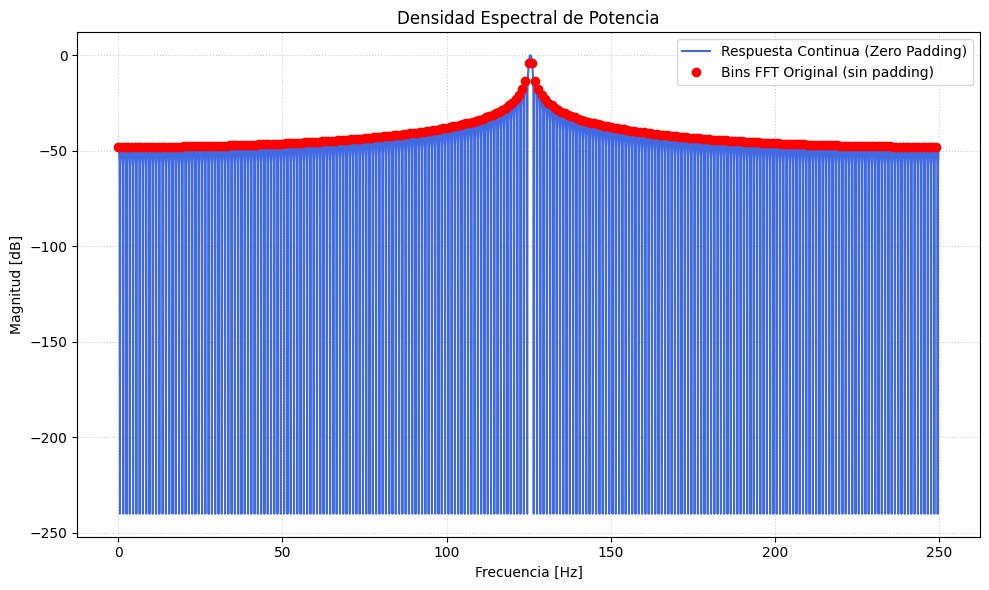

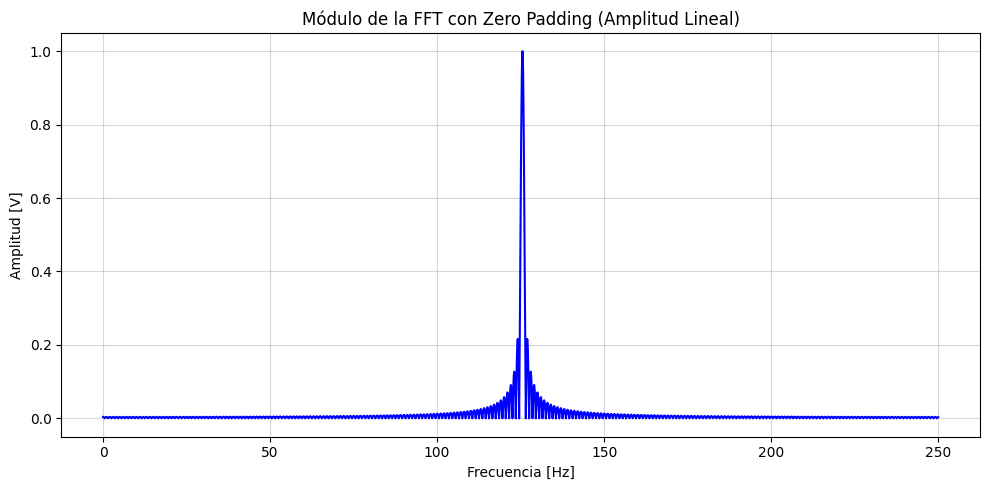

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# %% Función senoidal
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

# %% Parámetros
vmax = 1
dc = 0 
ph = 0 
nn = 500 
fs = 500 
df = fs / nn

# Frecuencias para probar (puedes cambiar 's' por s1, s2 o s3)
f1 = (nn/4) * df         # 125.0 Hz (Bin exacto)
f2 = (nn/4 + 0.25) * df  # 125.25 Hz
f3 = (nn/4 + 0.5) * df   # 125.5 Hz (Máxima fuga)

# %% Generación de señal y Padding
# Cambia f1 por f2 o f3 para ver cómo cambian los puntos rojos en el gráfico
tt, s = mi_funcion_sen(vmax, dc, f3, ph, nn, fs)

# Padding drástico para suavizar la curva (como en el libro)
cant_padds = 9
sf = np.concatenate((s, np.zeros(nn * cant_padds)))
N_total = len(sf)

# %% Cálculos FFT
# 1. Señal original seno
XX_s = np.fft.fft(s) / (nn/2)
modulo_s = np.abs(XX_s[:nn//2])
frec_s = np.arange(0, fs/2, df)

# 2. Señal con Zero Padding 
XX_sf = np.fft.fft(sf) / (nn/2)
modulo_sf = np.abs(XX_sf[:N_total//2])
frec_sf = np.linspace(0, fs/2, len(modulo_sf))

# Conversión a dB
S_dB = 20 * np.log10(modulo_s + 1e-12)
Sf_dB = 20 * np.log10(modulo_sf + 1e-12)

# %% FIGURA 1: Comparativa Bins vs Curva Continua (Estilo Libro)
plt.figure(figsize=(10, 6))
plt.plot(frec_sf, Sf_dB, '-', color='royalblue', linewidth=1.5, label='Respuesta Continua (Zero Padding)')
plt.plot(frec_s, S_dB, 'o', color='red', markersize=6, label='Bins FFT Original (sin padding)')

plt.title(f"Densidad Espectral de Potencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()

# %% FIGURA 2: Módulo Lineal con Zero Padding
plt.figure(figsize=(10, 5))
plt.plot(frec_sf, modulo_sf, color='blue', linewidth=1.5)
plt.title("Módulo de la FFT con Zero Padding (Amplitud Lineal)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [V]")
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.show()